In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy.abc import x, y, s

a_coeffs = [0,0,0,0]#don't use exactly 0 because downstream we will compute relative errors, and 0 would cause division by zero
b_coeffs = [3]#["4*exp(-(s/(2*0.1))**2)","exp(-(s/(2*0.1))**2)", "3*exp(-(s/(2*0.1))**2)", 3]

In [2]:
expansion = bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)

In [3]:
# Choose a fixed s value (e.g., s=0 for the magnet center)
s_fixed = 0.0

def ByiBx(x, y):#analytical definition of By + i*Bx at s=s_fixed
    return By_func(x, y, s_fixed) + 1j * Bx_func(x, y, s_fixed)

dkl = bpmeth.harmonics(ByiBx)
bpmeth.print_harmonics(dkl)
bnian=bpmeth.calc_coeffs(dkl)#bn+i*an
bn=bnian.real[:len(b_coeffs)]
an=bnian.imag[:len(a_coeffs)]

k  l=0                       l=1                       l=2                       
 0    3.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
 1    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
-1    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
 2    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
-2    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
 3    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
-3    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
 4    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
-4    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000


In [4]:
import sympy
#evaluate the original coefficients at s=s_fixed
a_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in a_coeffs]
b_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in b_coeffs]
print("Harmonic analysis results at s=", s_fixed)
print("recovered bn(s=",s_fixed,"):", bn)
print("Original b_coeffs(s):", b_coeffs_eval)
print("recovered an(s=",s_fixed,"):", an)
print("Original a_coeffs(s):", a_coeffs_eval)

Harmonic analysis results at s= 0.0
recovered bn(s= 0.0 ): [3.]
Original b_coeffs(s): [3]
recovered an(s= 0.0 ): [0. 0. 0. 0.]
Original a_coeffs(s): [0, 0, 0, 0]


/tmp/fmarcoli/ipykernel_14831/1947571475.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


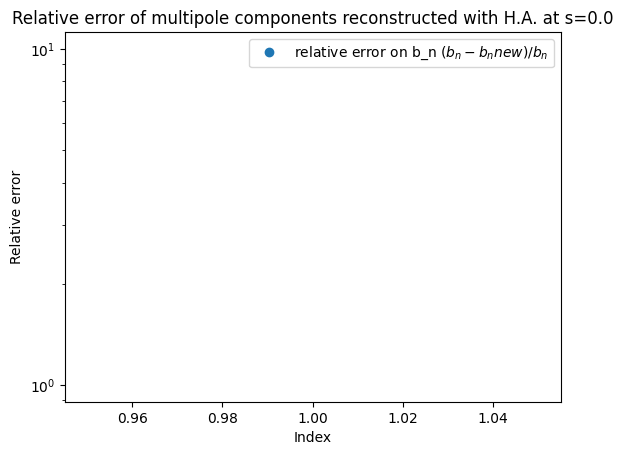

In [5]:
#plt.plot(range(1,len(a_coeffs)+1), (a_coeffs_eval-an)/a_coeffs_eval, 'o', label='relative error on a_n $(a_n - a_nnew)/a_n$')
plt.xlabel('Index')
plt.ylabel('Relative error')
plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed) )
plt.plot(range(1,len(b_coeffs)+1), (b_coeffs_eval-bn)/b_coeffs_eval, 'o', label='relative error on b_n $(b_n - b_nnew)/b_n$')
plt.legend()
plt.yscale("log")
plt.show()

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:129: PyVistaDeprecationWarning: `xlabel` is deprecated. Use `xtitle` instead.
  pl.show_bounds(
/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:129: PyVistaDeprecationWarning: `ylabel` is deprecated. Use `ytitle` instead.
  pl.show_bounds(
/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:129: PyVistaDeprecationWarning: `zlabel` is deprecated. Use `ztitle` instead.
  pl.show_bounds(
/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:139: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


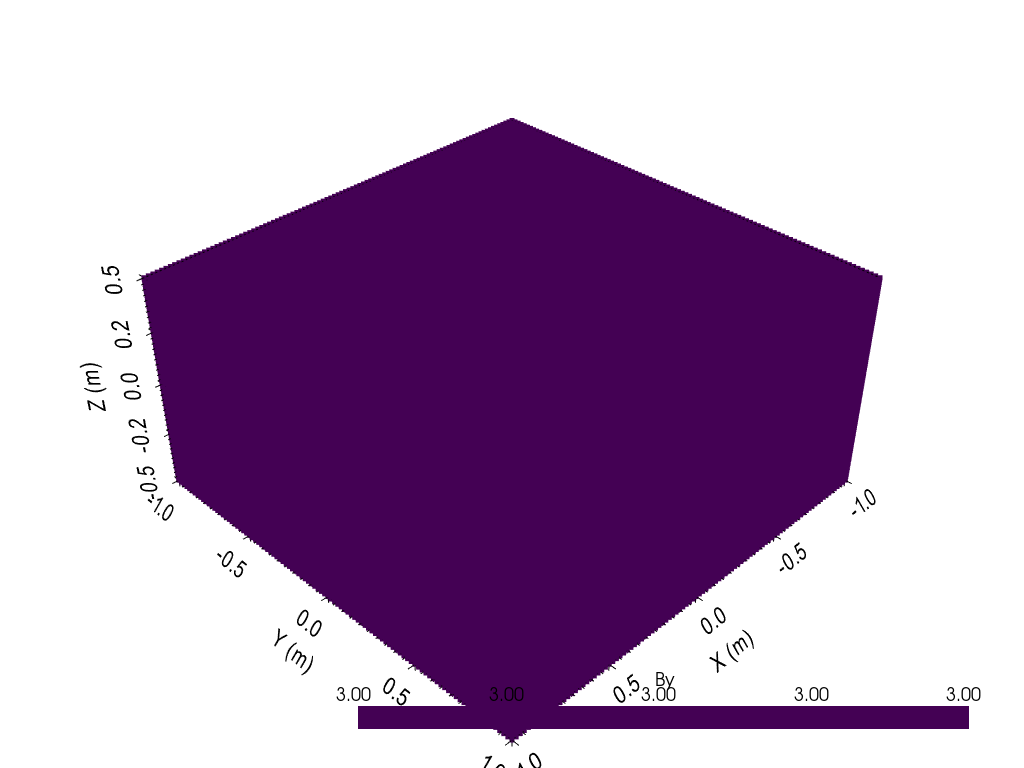

In [6]:
#make a fieldmap object
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-0.5,0.5,101)
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
fm.plot()

Harmonic analysis along the s axis

In [7]:
sv, recbn, stdrecbn = fm.s_harmonics(order=4, rmin=0.01, rmax=0.5, radius=0.03)

In [8]:
#evaluate the original coefficients along an s axis array
a_coeffs_eval_along_s = np.array([[sympy.sympify(coeff).subs(s, s_val) for coeff in a_coeffs] for s_val in sv])
b_coeffs_eval_along_s = np.array([[sympy.sympify(coeff).subs(s, s_val) for coeff in b_coeffs] for s_val in sv])

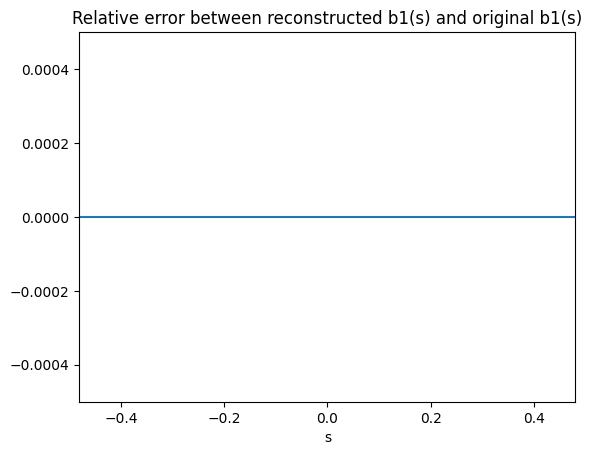

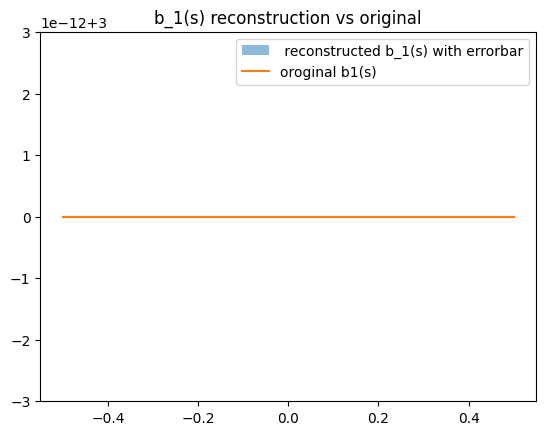

In [9]:
plt.plot(sv, (recbn[:,0]-b_coeffs_eval_along_s[:,0])/b_coeffs_eval_along_s[:,0])
plt.title('Relative error between reconstructed b1(s) and original b1(s)')
plt.xlabel('s')
plt.xlim((-0.48,0.48))
plt.ylim((-0.0005,0.0005))
plt.show()
plt.plot(sv, recbn[:,0])
plt.fill_between(sv, recbn[:,0]-stdrecbn[:,0], recbn[:,0]+stdrecbn[:,0], alpha=0.5, label=" reconstructed b_1(s) with errorbar")
plt.plot(sv, b_coeffs_eval_along_s[:,0], label="oroginal b1(s)")
plt.legend()
plt.title("b_1(s) reconstruction vs original")
plt.show()


In [10]:
plt.plot(sv, (recbn[:,1]-b_coeffs_eval_along_s[:,1])/(b_coeffs_eval_along_s[:,1]))
plt.title('Relative error between reconstructed b2(s) and original b2(s)')

plt.xlabel('s')
plt.show()
plt.plot(sv, recbn[:,1])
plt.fill_between(sv, recbn[:,1]-stdrecbn[:,1], recbn[:,1]+stdrecbn[:,1], alpha=0.5, label="recovered b_2(s) with errorbar")
plt.plot(sv, b_coeffs_eval_along_s[:,1], label="oroginal b2(s)")
plt.title("b2(s) reconstruction vs original")
plt.legend()
plt.show()


IndexError: index 1 is out of bounds for axis 1 with size 1